In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np

In [ ]:
# <Binning (구간화) 실습>

In [2]:
# 데이터 생성
ages = np.array([22, 25, 35, 45, 52, 58, 67, 72]).reshape(-1, 1) 

In [3]:
ages.shape # reshape(-1, 1)이 1차원에서 2차원으로 만들어줬음
# (8,)은 1차원
# (8,1)은 2차원
# (8,1,1)이 되면 3차원

(8, 1)

In [6]:
# Equal Width Binning
kbd_width = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
age_binned_width = kbd_width.fit_transform(ages)
age_binned_width

array([[0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [2.],
       [2.],
       [2.]])

In [7]:
print("Equal Width:", age_binned_width.ravel())

Equal Width: [0. 0. 0. 1. 1. 2. 2. 2.]


In [10]:
# Equal Frequency Binning  
kbd_freq = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
age_binned_freq = kbd_freq.fit_transform(ages)
age_binned_freq

/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


array([[0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [2.],
       [2.],
       [2.]])

In [11]:
print("Equal Frequency:", age_binned_freq.ravel())

Equal Frequency: [0. 0. 0. 1. 1. 2. 2. 2.]


In [ ]:
# Custom Binning with pandas
df = pd.DataFrame({'age': ages.ravel()})
df['age_group'] = pd.cut(df['age'],bins=[0, 30, 60, 100],labels=['청년', '중년', '노년'])
print(df)

In [15]:
X = np.array([1, 2, 3, 4, 5]).reshape(-1,1)
y = np.array([2, 7, 16, 29, 46])  # y = 2x² - 3x + 2

In [16]:
X.shape

(5, 1)

In [17]:
X

array([[1],
       [2],
       [3],
       [4],
       [5]])

In [18]:
# 1차 (선형) 모델
model_linear = LinearRegression()
model_linear.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
model_linear.predict([[6]])

array([53.])

In [21]:
# 2차 다항식 피처 생성
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
X_poly # 1 , X , X의 제곱

array([[ 1.,  1.,  1.],
       [ 1.,  2.,  4.],
       [ 1.,  3.,  9.],
       [ 1.,  4., 16.],
       [ 1.,  5., 25.]])

In [22]:
# 2차 다항식 모델
model_poly = LinearRegression()
model_poly.fit(X_poly, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
model_poly.predict(X_poly)

array([ 2.,  7., 16., 29., 46.])

In [26]:
from sklearn.pipeline import make_pipeline

In [30]:
model = make_pipeline(PolynomialFeatures(),LinearRegression())

In [31]:
model.fit(X,y)

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [32]:
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
import pandas as pd

In [33]:
# 데이터 로드
iris = load_iris()
X, y = iris.data, iris.target

In [35]:
# 1. F-statistic (ANOVA)
selector_f = SelectKBest(score_func=f_classif, k=2) # k=2 두개의 피쳐
X_f = selector_f.fit_transform(X, y)
X_f.shape

(150, 2)

In [36]:
print("F-statistic scores:", selector_f.scores_)
print("선택된 피처:", selector_f.get_support())

F-statistic scores: [ 119.26450218   49.16004009 1180.16118225  960.0071468 ]
선택된 피처: [False False  True  True]


In [59]:
# 2. Mutual Information
selector_mi = SelectKBest(score_func=mutual_info_classif, k=2) # k=2 두개의 피쳐
# 가장 뮤츄얼 결과 값이 가장 높은 두개의 피쳐를 만듬
X_mi = selector_mi.fit_transform(X, y)
X_mi.shape #

(569, 2)

In [60]:
print("MI scores:", selector_mi.scores_)

MI scores: [0.36691786 0.0968365  0.40349417 0.36120236 0.08813879 0.21126455
 0.37462354 0.43976321 0.07364952 0.00293327 0.24796609 0.0009317
 0.27739706 0.34030412 0.01555717 0.07671108 0.1186001  0.12833711
 0.01397751 0.04004503 0.45347739 0.11770694 0.47603925 0.46340526
 0.09806839 0.22389748 0.3156923  0.43442014 0.09062462 0.06791429]


In [40]:
# 3. Variance Threshold
from sklearn.feature_selection import VarianceThreshold

selector_var = VarianceThreshold(threshold=0.2)
X_var = selector_var.fit_transform(X)
X_var.shape

(150, 3)

In [61]:
print("Variance:", selector_var.variances_)
print("선택된 피처 수:", X_var.shape[1])

Variance: [0.68112222 0.18871289 3.09550267 0.57713289]
선택된 피처 수: 3


In [41]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer

In [42]:
# 데이터 로드
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

In [43]:
X.shape

(569, 30)

In [44]:
# RFE로 피처 선택
model = LogisticRegression(max_iter=10000)
rfe = RFE(estimator=model, n_features_to_select=10)
X_rfe = rfe.fit_transform(X, y)

In [46]:
from sklearn.model_selection import cross_val_score

In [47]:
score_all = cross_val_score(model, X,y , cv=5).mean()
score_rfe = cross_val_score(model, X_rfe,y, cv=5).mean()

In [48]:
score_all

np.float64(0.9525694767893184)

In [49]:
score_rfe 

np.float64(0.9525850023288308)

In [50]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# 데이터 로드
X, y = load_breast_cancer(return_X_y=True)

In [51]:
# 1. Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X, y)
lasso_coef = np.abs(lasso.coef_)
print("Lasso - 0인 계수:", np.sum(lasso_coef == 0))

Lasso - 0인 계수: 22


In [52]:
rf = DecisionTreeClassifier(max_depth=5, random_state=42)
rf.fit(X, y)
importances = rf.feature_importances_

In [53]:
importances

array([0.        , 0.01151705, 0.        , 0.        , 0.00716616,
       0.        , 0.        , 0.0089577 , 0.        , 0.        ,
       0.0059554 , 0.        , 0.        , 0.00956035, 0.00102519,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.71039073, 0.07127476, 0.00575852, 0.01132173, 0.01330367,
       0.        , 0.00187487, 0.14189385, 0.        , 0.        ])

In [55]:
# 상위 10개 중요 피처
indices = np.argsort(importances)[::-1][:10]
print("Top 10 중요 피처:")
for i in indices:
    print(f"{cancer.feature_names[i]}: {importances[i]:.4f}")

Top 10 중요 피처:
worst radius: 0.7104
worst concave points: 0.1419
worst texture: 0.0713
worst smoothness: 0.0133
mean texture: 0.0115
worst area: 0.0113
area error: 0.0096
mean concave points: 0.0090
mean smoothness: 0.0072
radius error: 0.0060


In [56]:
import matplotlib.pyplot as plt

([<matplotlib.axis.XTick at 0x15a999100>,
 [Text(0, 0, 'worst radius'),
  Text(1, 0, 'worst concave points'),
  Text(2, 0, 'worst texture'),
  Text(3, 0, 'worst smoothness'),
  Text(4, 0, 'mean texture'),
  Text(5, 0, 'worst area'),
  Text(6, 0, 'area error'),
  Text(7, 0, 'mean concave points'),
  Text(8, 0, 'mean smoothness'),
  Text(9, 0, 'radius error')])

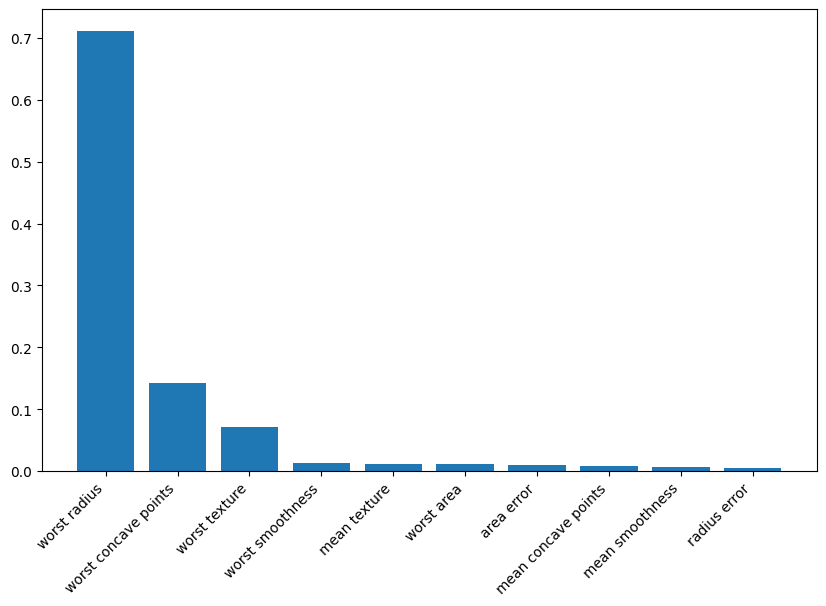

In [62]:
plt.figure(figsize=(10,6))
plt.bar(range(10), importances[indices])
plt.xticks(range(10), [cancer.feature_names[i] for i in indices], 
           rotation=45, ha='right')

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
import numpy as np
import matplotlib.pyplot as plt

# 데이터 생성 (다양한 밀도의 군집)
np.random.seed(42)
X1 = np.random.normal(0, 0.5, (100, 2))  # 조밀한 군집
X2 = np.random.normal(5, 1.5, (50, 2))   # 느슨한 군집
X_outliers = np.array([[7, 7], [-3, -3], [0, 5]])  # 이상치
X = np.vstack([X1, X2, X_outliers])

# LOF 적용
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
labels = lof.fit_predict(X)
scores = lof.negative_outlier_factor_

# 이상치 추출
outliers = X[labels == -1]
inliers = X[labels == 1]

print(f"정상 데이터: {len(inliers)}개")
print(f"이상치: {len(outliers)}개")
print(f"이상치 LOF scores: {scores[labels == -1]}")

# 시각화
plt.figure(figsize=(10, 6))
plt.scatter(inliers[:, 0], inliers[:, 1], c='blue', 
            alpha=0.6, s=50, label='Inliers')
plt.scatter(outliers[:, 0], outliers[:, 1], c='red', 
            s=200, marker='x', label='Outliers', linewidths=3)
plt.title('LOF Outlier Detection')
plt.legend()
plt.show()